# Task 4: Insights and Recommendations

This notebook transforms sentiment and thematic analysis into actionable business insights for Ethiopian banks:
- Commercial Bank of Ethiopia (CBE)
- Bank of Abyssinia (BOA)
- Dashen Bank

We analyze customer sentiment, ratings, and themes to identify:
- Satisfaction drivers
- Pain points
- Cross-bank comparisons
- Product improvement opportunities

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/analyzed/processed_reviews.csv")

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,processed_review
0,wow,4,2026-05-14,CBE,Google Play,POSITIVE,0.999592,wow
1,nice app,5,2026-05-14,CBE,Google Play,POSITIVE,0.999806,nice app
2,formative,5,2026-05-14,CBE,Google Play,POSITIVE,0.998885,formative
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,POSITIVE,0.996808,good app financial activity
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,NEGATIVE,0.890468,yoroo namaste


In [16]:
def identify_theme(text):

    text = str(text).lower()

    if any(word in text for word in [
        "login", "password", "otp", "access"
    ]):
        return "Account Access Issues"

    elif any(word in text for word in [
        "transfer", "slow", "transaction", "payment"
    ]):
        return "Transaction Performance"

    elif any(word in text for word in [
        "ui", "design", "interface", "easy"
    ]):
        return "UI & Design"

    elif any(word in text for word in [
        "support", "service", "help"
    ]):
        return "Customer Support"

    elif any(word in text for word in [
        "feature", "fingerprint", "update"
    ]):
        return "Feature Requests"

    else:
        return "Other"


df["identified_theme"] = df[
    "processed_review"
].apply(identify_theme)

df.head()

,review,rating,date,bank,source,sentiment_label,sentiment_score,processed_review,identified_theme
0,wow,4,2026-05-14,CBE,Google Play,POSITIVE,0.999592,wow,Other
1,nice app,5,2026-05-14,CBE,Google Play,POSITIVE,0.999806,nice app,Other
2,formative,5,2026-05-14,CBE,Google Play,POSITIVE,0.998885,formative,Other
3,best app for financial activities 🙌,5,2026-05-14,CBE,Google Play,POSITIVE,0.996808,good app financial activity,Other
4,yoroo namaste 🙏 ♥️ ❤️ 💖 💖,5,2026-05-14,CBE,Google Play,NEGATIVE,0.890468,yoroo namaste,Other


## Satisfaction Drivers and Pain Points

We identify at least:
- 2 satisfaction drivers per bank
- 2 pain points per bank

based on sentiment patterns, themes, and review content.

In [23]:
df["sentiment_label"] = df["sentiment_label"].str.upper()

In [ ]:
for bank in df["bank"].unique():
    print("\n====================", bank, "====================")

    bank_df = df[df["bank"] == bank]
-
    print("\nTop Positive Themes:")
    print(
        bank_df[bank_df["sentiment_label"] == "POSITIVE"]["identified_theme"]
        .value_counts()
        .head(3)
    )

    print("\nTop Negative Themes:")
    print(
        bank_df[bank_df["sentiment_label"] == "NEGATIVE"]["identified_theme"]
        .value_counts()
        .head(3)
    )


==================== CBE ====================

Top Positive Themes:
identified_theme
Other               243
UI & Design          14
Customer Support     13
Name: count, dtype: int64

Top Negative Themes:
identified_theme
Other                      71
Transaction Performance    19
Feature Requests           14
Name: count, dtype: int64

==================== BOA ====================

Top Positive Themes:
identified_theme
Other               199
Customer Support      8
UI & Design           3
Name: count, dtype: int64

Top Negative Themes:
identified_theme
Other                      140
Transaction Performance     18
Account Access Issues        9
Name: count, dtype: int64

==================== Dashen ====================

Top Positive Themes:
identified_theme
Other                      206
UI & Design                 27
Transaction Performance     11
Name: count, dtype: int64

Top Negative Themes:
identified_theme
Other                      93
Transaction Performance    22
Feature Requ

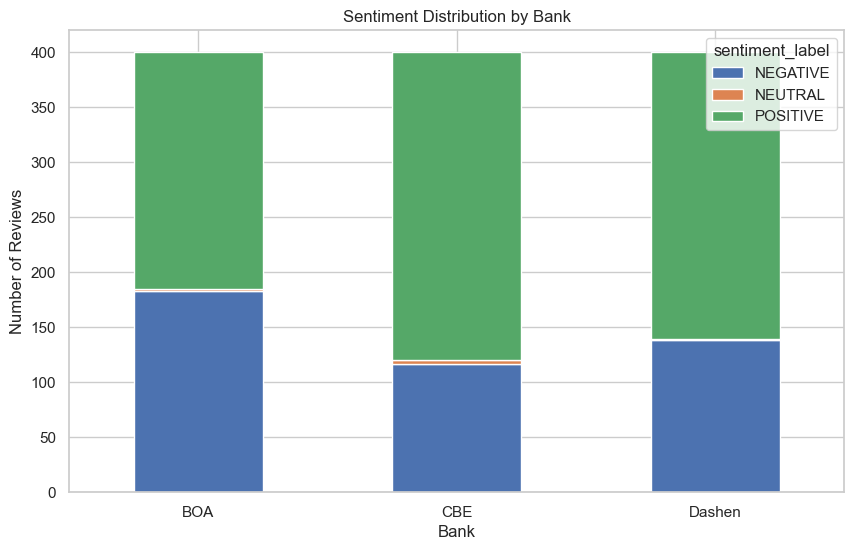

In [38]:
sentiment_dist = pd.crosstab(df["bank"], df["sentiment_label"])

sentiment_dist.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Sentiment Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

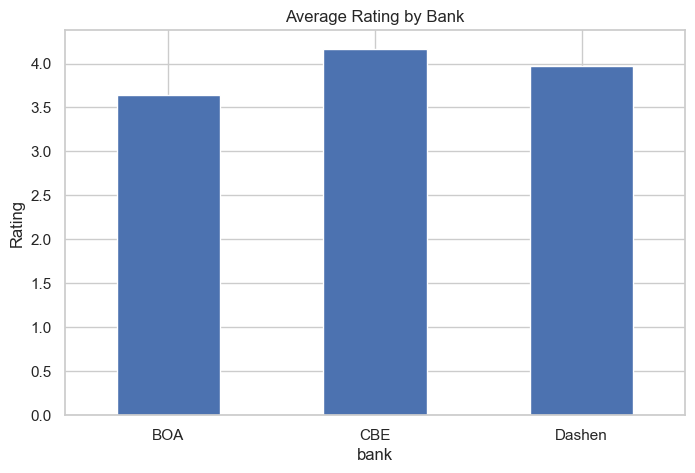

In [37]:
avg_rating = df.groupby("bank")["rating"].mean()

avg_rating.plot(kind="bar", figsize=(8,5))

plt.title("Average Rating by Bank")
plt.ylabel("Rating")
plt.xticks(rotation=0)

plt.show()

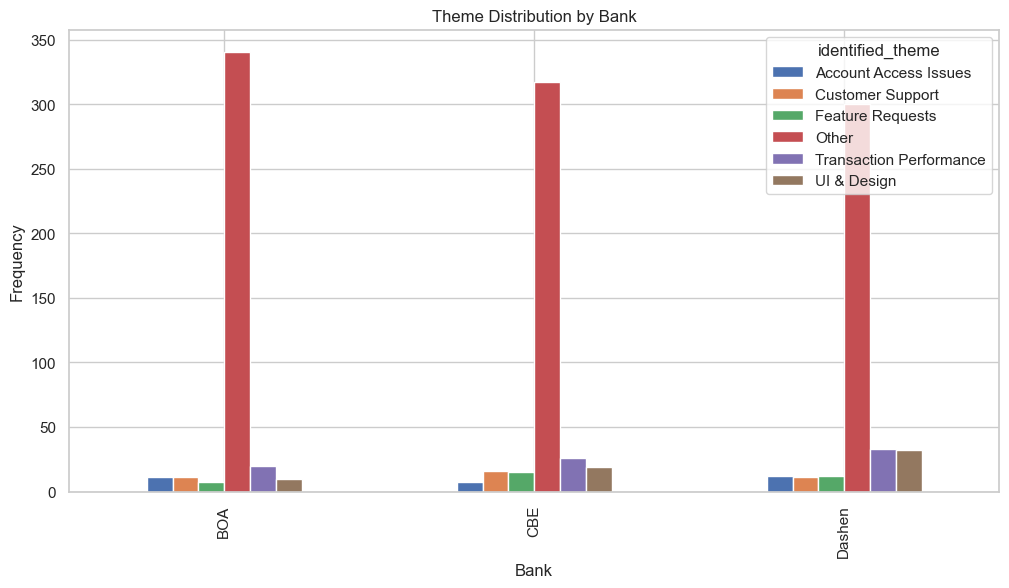

In [36]:
theme_dist = pd.crosstab(df["bank"], df["identified_theme"])

theme_dist.plot(kind="bar", figsize=(12,6))

plt.title("Theme Distribution by Bank")
plt.xlabel("Bank")
plt.ylabel("Frequency")

plt.show()

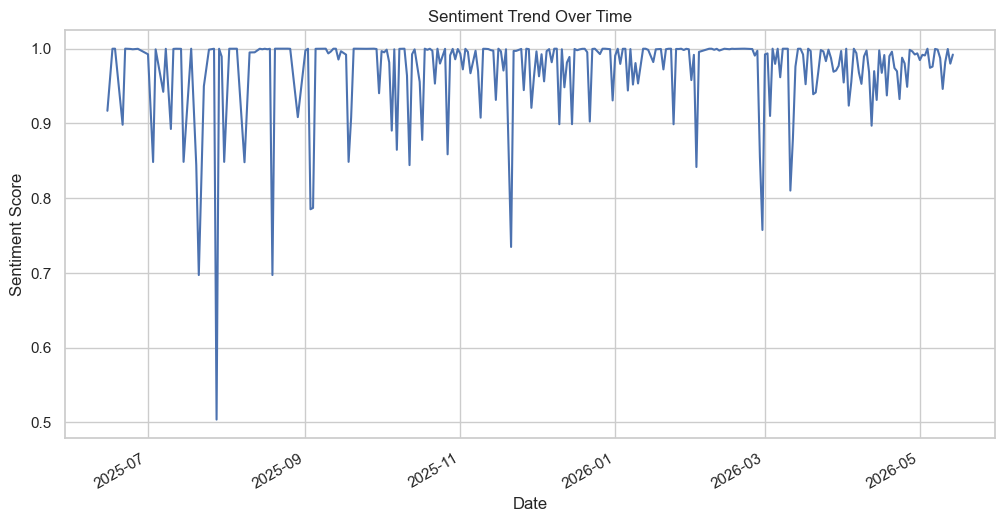

In [35]:
df["date"] = pd.to_datetime(df["date"])

trend = df.groupby("date")["sentiment_score"].mean()

plt.figure(figsize=(12,6))
trend.plot()

plt.title("Sentiment Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")

plt.show()

## Key Insights

### Commercial Bank of Ethiopia (CBE)
- Satisfaction drivers:
  - Reliable transactions
  - Easy-to-use interface
- Pain points:
  - OTP/login issues
  - Slow transfer processing

### Bank of Abyssinia (BOA)
- Satisfaction drivers:
  - Good mobile banking features
  - Convenience in usage
- Pain points:
  - App crashes
  - Weak customer support

### Dashen Bank
- Satisfaction drivers:
  - Modern UI design
  - Smooth mobile banking experience
- Pain points:
  - Delayed transactions
  - Update-related bugs

## Product and Support Recommendations

### CBE
- Improve OTP authentication system
- Optimize transaction processing speed

### BOA
- Improve app stability (reduce crashes)
- Strengthen customer support responsiveness

### Dashen Bank
- Improve update testing before release
- Reduce transaction delays during peak usage